# Estimation du prix d'un logement Airbnb dans Paris

## Objectif du projet

## Prédire le prix moyen journalier des logements Airbnb à Paris en analysant les facteurs influençant ce prix.

## Partie 1 : Préparations pour le ML

### 1.Importations des données enrichies 

In [1]:
import pandas as pd   #bibliothéques nécessaires au projet
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.ensemble import RandomForestRegressor

In [2]:
df_sept = pd.read_csv("DATA/listings_sept2024_clean.csv")
df_dec = pd.read_csv("DATA/listings_dec2024_clean.csv")
df_mars = pd.read_csv("DATA/listings_mars2025_clean.csv")

In [3]:
df_sept.head() 

,id,neighbourhood,latitude,longitude,availability_365,number_of_reviews,reviews_per_month,minimum_nights,distance_seine,prix_moyen_journalier,periode
0,371299,Hôtel-de-Ville,48.857510,2.355110,307,601,3.97,3,379.074605,195.0,sept_2024
1,390984,Buttes-Montmartre,48.885738,2.340673,262,425,2.85,3,2897.446887,220.0,sept_2024
2,395585,Batignolles-Monceau,48.889380,2.292010,144,57,0.38,2,1501.325730,400.0,sept_2024
3,398860,Temple,48.869220,2.354450,148,30,0.31,5,1498.021482,220.0,sept_2024
4,406902,Hôtel-de-Ville,48.853240,2.368400,174,328,2.18,2,620.952987,120.0,sept_2024


In [4]:
print(df_sept["periode"].unique()) # On vérifie l'existence de la colonne dans chaque dataframe et que les intitulés sont les mêmes
print(df_dec["periode"].unique())
print(df_mars["periode"].unique())

['sept_2024']
['dec_2024']
['mars_2025']


### 2.Fusion des datasets

In [5]:
df = pd.concat([df_sept, df_dec, df_mars], ignore_index=True)

In [6]:
df["periode"].value_counts() #on a vérifié que la fusion est ok avec le nombre de logements par périodes

periode
dec_2024     29346
sept_2024    28213
mars_2025    25064
Name: count, dtype: int64

In [7]:
df.info() # Tout est ok pour la suite!

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82623 entries, 0 to 82622
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     82623 non-null  int64  
 1   neighbourhood          82623 non-null  object 
 2   latitude               82623 non-null  float64
 3   longitude              82623 non-null  float64
 4   availability_365       82623 non-null  int64  
 5   number_of_reviews      82623 non-null  int64  
 6   reviews_per_month      63703 non-null  float64
 7   minimum_nights         82623 non-null  int64  
 8   distance_seine         82623 non-null  float64
 9   prix_moyen_journalier  82623 non-null  float64
 10  periode                82623 non-null  object 
dtypes: float64(5), int64(4), object(2)
memory usage: 6.9+ MB


### 3.Ajout de la distance au centre de Paris et gestion des valeurs manquantes 

#### Coordonnées centre :

#### lat = 48.8566
#### lon = 2.3522

#### Fonction distance(Haversine simple)

In [8]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # rayon Terre en km
    
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

#### Application:

In [9]:
df["distance_centre"] = haversine(
    df["latitude"],
    df["longitude"],
    48.8566,
    2.3522
)

#### Vérifications rapides:

In [10]:
df.head()

,id,neighbourhood,latitude,longitude,availability_365,number_of_reviews,reviews_per_month,minimum_nights,distance_seine,prix_moyen_journalier,periode,distance_centre
0,371299,Hôtel-de-Ville,48.857510,2.355110,307,601,3.97,3,379.074605,195.0,sept_2024,0.235718
1,390984,Buttes-Montmartre,48.885738,2.340673,262,425,2.85,3,2897.446887,220.0,sept_2024,3.347888
2,395585,Batignolles-Monceau,48.889380,2.292010,144,57,0.38,2,1501.325730,400.0,sept_2024,5.715247
3,398860,Temple,48.869220,2.354450,148,30,0.31,5,1498.021482,220.0,sept_2024,1.412899
4,406902,Hôtel-de-Ville,48.853240,2.368400,174,328,2.18,2,620.952987,120.0,sept_2024,1.242728


In [11]:
df.describe()

,id,latitude,longitude,availability_365,number_of_reviews,reviews_per_month,minimum_nights,distance_seine,prix_moyen_journalier,distance_centre
count,8.262300e+04,82623.000000,82623.000000,82623.000000,82623.000000,63703.000000,82623.000000,82623.000000,82623.000000,82623.000000
mean,7.604432e+17,48.864354,2.343651,221.020975,31.544388,1.509018,2.538833,1889.316966,198.751445,3.027827
std,4.754065e+17,0.017974,0.033793,107.656196,64.138833,1.448130,1.463867,1107.732538,104.835542,1.439825
min,3.109000e+03,48.815890,2.251593,1.000000,0.000000,0.000000,1.000000,0.226225,10.000000,0.002173
25%,5.346953e+07,48.851409,2.322714,139.000000,1.000000,0.500000,1.000000,983.594932,120.000000,1.844380
50%,9.681583e+17,48.865630,2.347540,247.000000,9.000000,1.060000,2.000000,1757.068040,170.000000,3.130087
75%,1.130435e+18,48.878802,2.367524,316.000000,33.000000,2.050000,3.000000,2726.718537,250.000000,4.061618
max,1.367953e+18,48.899990,2.416250,365.000000,957.000000,62.880000,7.000000,5814.824141,500.000000,7.579292


In [12]:
df.isnull().sum()

id                           0
neighbourhood                0
latitude                     0
longitude                    0
availability_365             0
number_of_reviews            0
reviews_per_month        18920
minimum_nights               0
distance_seine               0
prix_moyen_journalier        0
periode                      0
distance_centre              0
dtype: int64

In [13]:
df.sample(15)

,id,neighbourhood,latitude,longitude,availability_365,number_of_reviews,reviews_per_month,minimum_nights,distance_seine,prix_moyen_journalier,periode,distance_centre
55405,1223222749366066352,Reuilly,48.845540,2.394850,322,7,2.36,2,1663.429668,260.0,dec_2024,3.354217
77871,1179885364735437180,Batignolles-Monceau,48.884910,2.316920,52,6,0.70,3,2351.858833,100.0,mars_2025,4.070347
42106,939028365423950850,Popincourt,48.852960,2.394230,249,97,5.76,1,2125.414512,145.0,dec_2024,3.101560
24165,1155594234379048453,Batignolles-Monceau,48.895044,2.321452,251,0,NaN,1,3061.917821,80.0,sept_2024,4.830167
21479,1123065834678914755,Hôtel-de-Ville,48.860018,2.353794,266,9,1.86,5,558.492128,137.0,sept_2024,0.397605
22466,1134921175900991774,Popincourt,48.864032,2.378353,152,0,NaN,5,1916.669291,150.0,sept_2024,2.084030
46107,1060823997305272326,Popincourt,48.859659,2.369393,273,13,1.20,3,1114.957563,497.0,dec_2024,1.302947
11125,862965973195171441,Buttes-Chaumont,48.899296,2.383412,258,2,0.12,3,5435.935422,100.0,sept_2024,5.267740
19305,1094850755754138578,Reuilly,48.844639,2.402334,68,0,NaN,2,2032.161045,200.0,sept_2024,3.901942
67454,856984923618449132,Hôtel-de-Ville,48.857820,2.357520,315,29,1.29,3,503.714090,233.0,mars_2025,0.412172


In [14]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

In [15]:
df["reviews_per_month"].isnull().sum()

np.int64(0)

#### Les valeurs manquantes correspondaient à des logements sans avis, j’ai donc remplacé les NaN par 0 pour refléter la réalité métier.

### 4.Analyse de la relation entre les variables numériques (matrice de corrélation)

In [16]:
correlation=df[['availability_365','number_of_reviews','reviews_per_month','minimum_nights','distance_seine','prix_moyen_journalier','distance_centre']].corr()

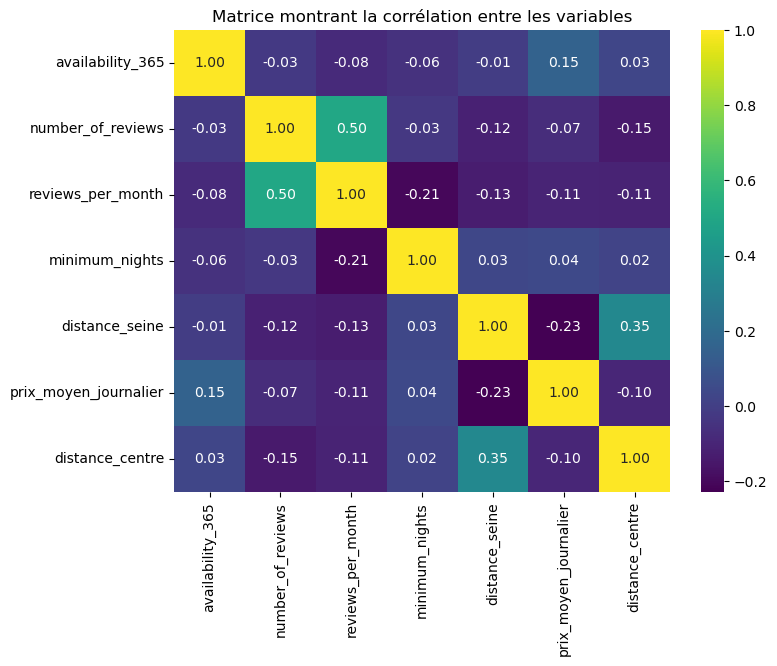

In [17]:
# Création de la heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='viridis', fmt=".2f")
plt.title('Matrice montrant la corrélation entre les variables')
plt.show()

In [18]:
print(correlation["prix_moyen_journalier"].sort_values(ascending=False))

prix_moyen_journalier    1.000000
availability_365         0.151868
minimum_nights           0.043666
number_of_reviews       -0.071711
distance_centre         -0.095742
reviews_per_month       -0.105873
distance_seine          -0.228522
Name: prix_moyen_journalier, dtype: float64


In [19]:
df.groupby("neighbourhood")["prix_moyen_journalier"].mean().sort_values(ascending=False)

neighbourhood
Palais-Bourbon         249.150372
Luxembourg             247.997124
Louvre                 245.095532
Élysée                 243.722536
Hôtel-de-Ville         230.368978
Bourse                 228.246746
Passy                  227.625903
Temple                 223.026027
Panthéon               220.294464
Opéra                  212.414694
Vaugirard              202.537810
Batignolles-Monceau    193.342324
Entrepôt               190.915152
Popincourt             183.038710
Observatoire           182.562347
Gobelins               176.297256
Reuilly                171.061406
Buttes-Montmartre      168.922785
Buttes-Chaumont        164.506679
Ménilmontant           156.098293
Name: prix_moyen_journalier, dtype: float64


#### L’analyse de corrélation montre que :

#### Aucune variable n’est fortement corrélée individuellement au prix
#### La distance à la Seine est la variable la plus corrélée négativement
#### La localisation joue un rôle important.
#### Une analyse par quartier confirme que certains quartiers ont des prix significativement plus élevés que d’autres.Je vais donc intégrer cette variable dans mon modèle via un encodage pour améliorer la prédiction.

## Modélisation

### Dans cette partie, nous allons entraîner différents modèles afin de prédire le prix des logements et comparer leurs performances.

## Partie2 : Estimation du prix moyen journalier par la méthode de regression linéaire multiple

### 1. Séparation des variables features et target // Création du modèle d'entrainement

In [20]:
features = [
    "availability_365",
    "number_of_reviews",
    "reviews_per_month",
    "minimum_nights",
    "distance_seine",
    "distance_centre",
    "neighbourhood",
    "periode"
]

In [21]:
X=df[features]

In [22]:
X = pd.get_dummies(X, columns=["neighbourhood", "periode"])  # Il s'agit d'encoder les colonnes qui ne sont pas numériques mais qui ont leur importance

In [23]:
Y=df['prix_moyen_journalier'] 

In [24]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42) # Séparation en ensemble d'entraînement et ensemble de test avec un ratio de 20%

In [25]:
model = LinearRegression() # construction du modèle de régression linéaire multiple grâce à la base sklearn

In [26]:
model.fit(X_train, Y_train) # Entraînement du modèle 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
Y_pred = model.predict(X_test) # calcul de prédiction

### 2. Détermination des coefficients de correlation et de détermination

In [28]:
# Calcul des coefficients de correlation (RMSE) et de détermination (R²)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)

print("RMSE RF:", rmse)
print("R2 RF:", r2_score(Y_test, Y_pred))

RMSE RF: 98.24706126981361
R2 RF: 0.11155698099107736


#### Le modèle explique une partie limitée de la variance des prix, ce qui est cohérent avec la complexité du marché Airbnb.

### 3.Coefficients des différentes variables et influences

In [29]:
print(f'Intercept: {model.intercept_}')

Intercept: 231.4790490117507


In [30]:
coef = pd.DataFrame({
    "feature": X.columns,
    "coef": model.coef_
}).sort_values(by="coef", ascending=False)

print(coef)

                              feature       coef
25               neighbourhood_Élysée  38.267262
18       neighbourhood_Palais-Bourbon  30.190530
20                neighbourhood_Passy  25.364382
14           neighbourhood_Luxembourg  19.219944
17                neighbourhood_Opéra  13.201517
13               neighbourhood_Louvre  13.013945
6   neighbourhood_Batignolles-Monceau  10.640887
7                neighbourhood_Bourse   6.549772
24            neighbourhood_Vaugirard   6.390717
3                      minimum_nights   3.123424
27                  periode_mars_2025   1.851335
28                  periode_sept_2024   1.648414
16         neighbourhood_Observatoire   1.056096
0                    availability_365   0.136720
4                      distance_seine  -0.016981
1                   number_of_reviews  -0.095178
8       neighbourhood_Buttes-Chaumont  -0.351458
9     neighbourhood_Buttes-Montmartre  -3.019601
26                   periode_dec_2024  -3.499749
23               nei

#### Les coefficients du modèle montrent que :
#### Les quartiers centraux et prestigieux ont un impact positif significatif sur le prix
#### La distance au centre a un impact négatif
#### Les autres variables ont un effet plus modéré
#### La localisation apparaît comme le facteur déterminant.

#### La distance à la Seine présente une corrélation négative avec le prix, mais son effet devient limité dans le modèle une fois les quartiers pris en compte, ce qui suggère que l’information géographique est en grande partie capturée par la variable de localisation

## Partie3:Estimation du prix journalier moyen par la méthode Random Forest

### 1.Model d'entraînement

In [31]:
model_rf = RandomForestRegressor(random_state=42)

model_rf.fit(X_train, Y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 2.Prédiction

In [32]:
Y_pred_rf = model_rf.predict(X_test)

### 3.Evaluation 

In [33]:
mse = mean_squared_error(Y_test, Y_pred_rf)
rmse = np.sqrt(mse)

print("RMSE RF:", rmse)
print("R2 RF:", r2_score(Y_test, Y_pred_rf))

RMSE RF: 82.12444863161612
R2 RF: 0.37922334667190016


#### Le modèle de régression linéaire présentait des performances limitées, avec un R² d’environ 0.11. L’utilisation d’un modèle Random Forest a permis d’améliorer significativement la performance (R² ≈ 0.38), en capturant des relations non linéaires et des interactions entre variables.

### 4.Importance des variables

In [34]:
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": model_rf.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importances)

                              feature  importance
4                      distance_seine    0.250672
5                     distance_centre    0.206718
0                    availability_365    0.150649
2                   reviews_per_month    0.129168
1                   number_of_reviews    0.100018
3                      minimum_nights    0.053209
28                  periode_sept_2024    0.010789
27                  periode_mars_2025    0.009146
26                   periode_dec_2024    0.008562
22              neighbourhood_Reuilly    0.008341
11             neighbourhood_Gobelins    0.007646
21           neighbourhood_Popincourt    0.006907
24            neighbourhood_Vaugirard    0.006400
17                neighbourhood_Opéra    0.005946
15         neighbourhood_Ménilmontant    0.004401
9     neighbourhood_Buttes-Montmartre    0.004214
25               neighbourhood_Élysée    0.004195
14           neighbourhood_Luxembourg    0.004027
16         neighbourhood_Observatoire    0.003389


#### L’analyse d’importance des variables avec le modèle Random Forest montre que les variables géographiques continues, notamment la distance à la Seine et au centre de Paris, sont les plus déterminantes. Contrairement à la régression linéaire, où les quartiers avaient un poids important, le modèle non linéaire capte directement l’effet de la localisation à travers ces distances.

## Comparaison des modèles

### - Régression linéaire : R² ≈ 0.11, RMSE ≈ 100€
### - Random Forest : R² ≈ 0.38, RMSE ≈ 82€

### 👉 Le modèle Random Forest améliore significativement la performance en capturant des relations non linéaires.

## Conclusion générale du projet

#### Ce projet avait pour objectif d’analyser les facteurs influençant les prix des logements Airbnb à Paris et de développer un modèle capable de prédire le prix moyen journalier.

#### L’analyse exploratoire a mis en évidence l’importance de la localisation, notamment à travers la proximité de la Seine et du centre de Paris, ainsi que des disparités significatives entre les quartiers.

#### Un premier modèle de régression linéaire a permis d’identifier certaines relations entre variables, mais avec des performances limitées (R² ≈ 0.11), soulignant la complexité du phénomène étudié et les limites d’un modèle linéaire face à des relations potentiellement non linéaires.

#### L’utilisation d’un modèle Random Forest a permis d’améliorer significativement les performances (R² ≈ 0.38), en capturant des interactions et des effets non linéaires entre les variables. L’analyse des importances a confirmé que les variables géographiques continues, notamment la distance à la Seine et au centre, sont les plus déterminantes dans la prédiction des prix.

#### Ce projet met ainsi en évidence le rôle central de la localisation dans la formation des prix Airbnb, tout en illustrant l’intérêt d’utiliser des modèles plus avancés pour mieux appréhender la complexité des données.

#### Enfin, certaines limites subsistent, notamment l’absence de variables qualitatives (standing, équipements, caractéristiques du logement), qui pourraient permettre d’améliorer davantage la précision des modèles.